<a href="https://colab.research.google.com/github/Lijan-Baral/GitHub-CST184/blob/main/Week12_tutorialForecasting_Renewable_Energy_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Scenario: You are a data analyst working for an international policy group preparing projections for SDG 7: Affordable and Clean Energy. Your team must report on renewable energy adoption trends and forecast future progress toward 2030 goals.

You have access to renewable energy data from 1990 to 2022. Your task is to:

Visualize the trend
Smooth and clean the data
Apply ARIMA models to forecast to 2030
Experiment with assumptions and interpret findings

Step 1 – Load and Inspect the Data

In [13]:
data <- read.csv("/content/sdg7_renewable_energy_percent.csv")
head(data)
summary(data)

,Year,Renewable_Energy_Percent
,<int>,<dbl>
1,1990,12.75
2,1991,12.26
3,1992,13.91
4,1993,15.69
5,1994,13.52
6,1995,13.99


      Year      Renewable_Energy_Percent
 Min.   :1990   Min.   :12.26           
 1st Qu.:1998   1st Qu.:15.98           
 Median :2006   Median :18.19           
 Mean   :2006   Mean   :19.30           
 3rd Qu.:2014   3rd Qu.:22.46           
 Max.   :2022   Max.   :29.31           

Any missing years?-No

Are values realistic (10–40%)?-YES

Step 2 – Visualize the Raw Trend

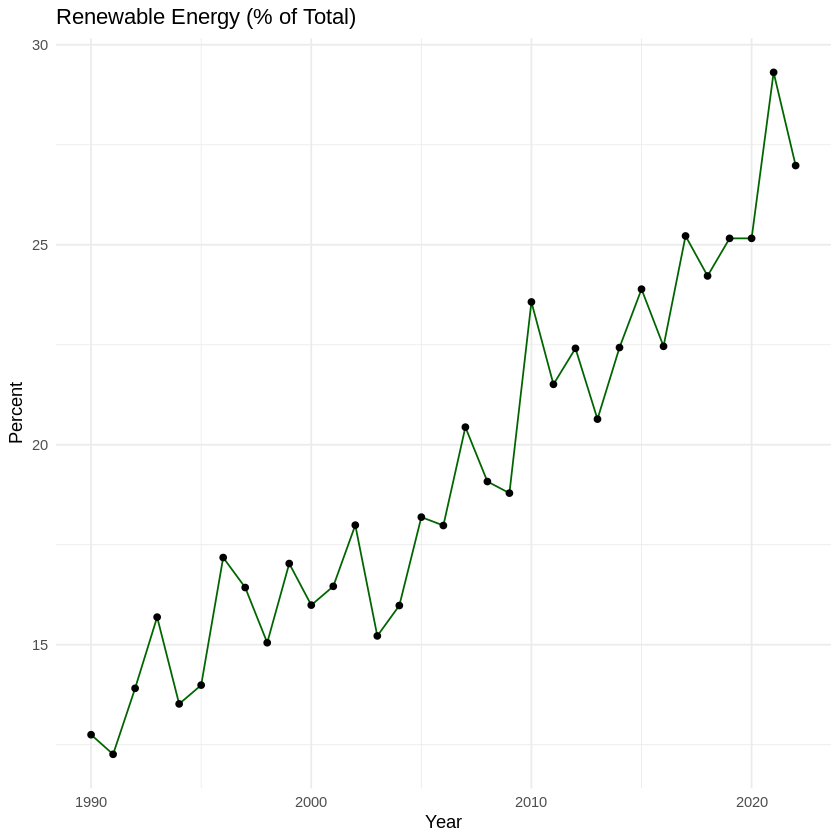

In [14]:
library(ggplot2)

ggplot(data, aes(x = Year, y = Renewable_Energy_Percent)) +
  geom_line(color = "darkgreen") +
  geom_point() +
  labs(title = "Renewable Energy (% of Total)", y = "Percent", x = "Year") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


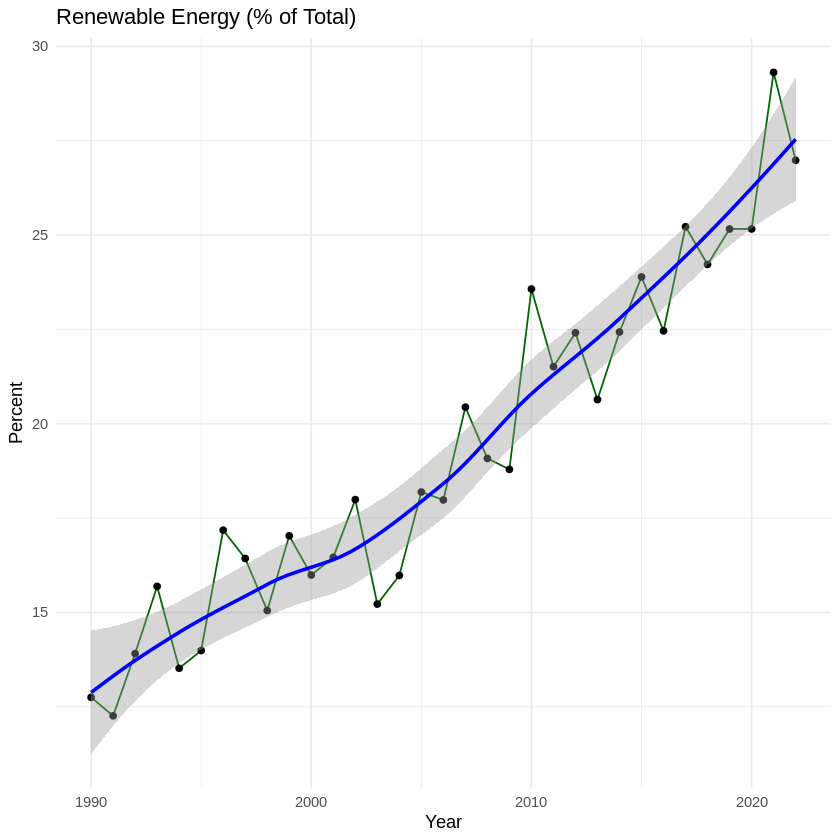

In [15]:
#Prompt: Add a geom_smooth() line. What does it show about the long-term trend?
#It shows the smooth line reveals a clear, consistent upward trajectory

ggplot(data, aes(x = Year, y = Renewable_Energy_Percent)) +
  geom_line(color = "darkgreen") +
  geom_point() +
  geom_smooth(method = "loess", se = TRUE, color = "blue") +
  labs(title = "Renewable Energy (% of Total)", y = "Percent", x = "Year") +
  theme_minimal()

Step 3 – Create a Time Series Object

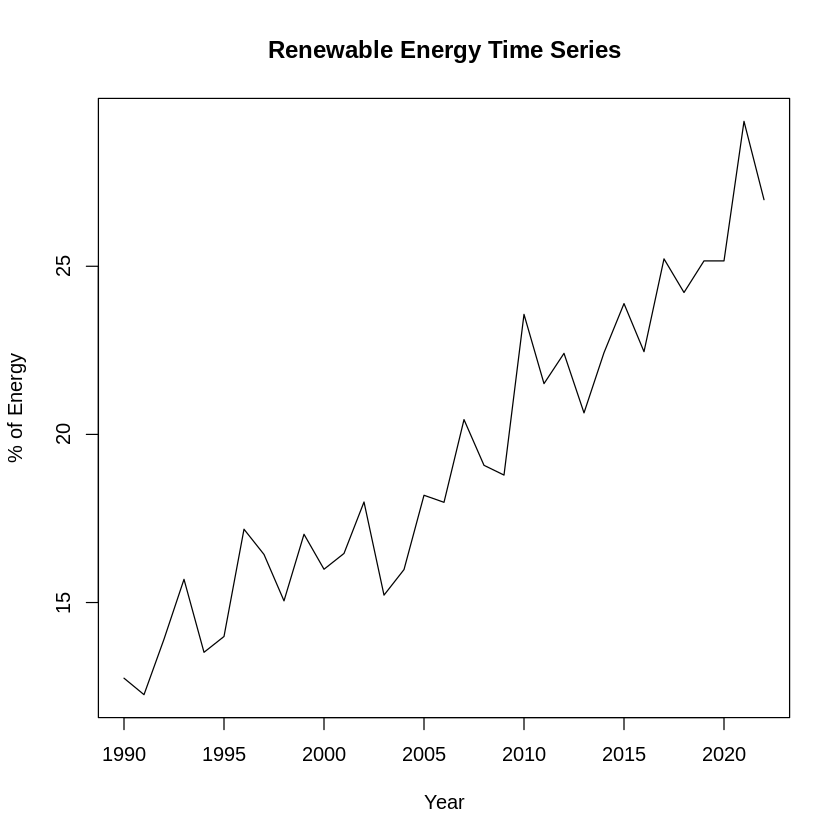

In [16]:
ts_data <- ts(data$Renewable_Energy_Percent, start = 1990, frequency = 1)
plot(ts_data, main = "Renewable Energy Time Series", ylab = "% of Energy", xlab = "Year")

Step 4 – Check for Stationarity

In [17]:
install.packages("tseries")
library(tseries)

adf.test(ts_data)  # Augmented Dickey-Fuller Test

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




	Augmented Dickey-Fuller Test

data:  ts_data
Dickey-Fuller = -1.4986, Lag order = 3, p-value = 0.7668
alternative hypothesis: stationary


Interpretation: If p-value > 0.05, the data is non-stationary. Differencing will be needed.

Warning message in adf.test(diff_ts):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  diff_ts
Dickey-Fuller = -4.445, Lag order = 3, p-value = 0.01
alternative hypothesis: stationary


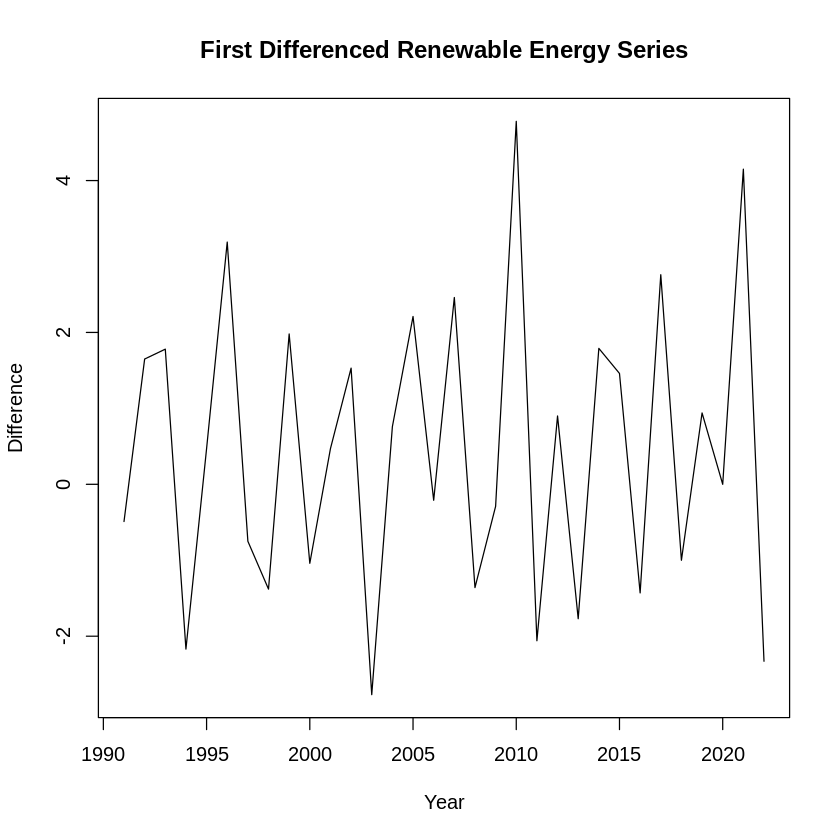

In [18]:
#first difference
diff_ts <- diff(ts_data)

# Plot the differenced series
plot(diff_ts, main = "First Differenced Renewable Energy Series", ylab = "Difference", xlab = "Year")

# Run Augmented Dickey-Fuller test on the differenced data
adf.test(diff_ts)

Step 5 – Apply ARIMA for Forecasting

In [19]:
install.packages("forecast")
library(forecast)

model <- auto.arima(ts_data)
summary(model)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Series: ts_data 
ARIMA(0,1,1) with drift 

Coefficients:
          ma1   drift
      -0.8272  0.4483
s.e.   0.1485  0.0524

sigma^2 = 2.142:  log likelihood = -57.14
AIC=120.28   AICc=121.14   BIC=124.68

Training set error measures:
                      ME     RMSE      MAE        MPE    MAPE     MASE
Training set -0.02003848 1.395607 1.056973 -0.8469776 5.71951 0.646343
                   ACF1
Training set -0.0750061

Step 6 – Forecast to 2030

     Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
2023       27.32382 25.44798 29.19966 24.45497 30.19267
2024       27.77212 25.86849 29.67575 24.86077 30.68347
2025       28.22041 26.28939 30.15143 25.26717 31.17365
2026       28.66871 26.71068 30.62674 25.67416 31.66325
2027       29.11700 27.13233 31.10167 26.08171 32.15229
2028       29.56530 27.55434 31.57625 26.48981 32.64079
2029       30.01359 27.97669 32.05049 26.89842 33.12877
2030       30.46189 28.39936 32.52441 27.30753 33.61625

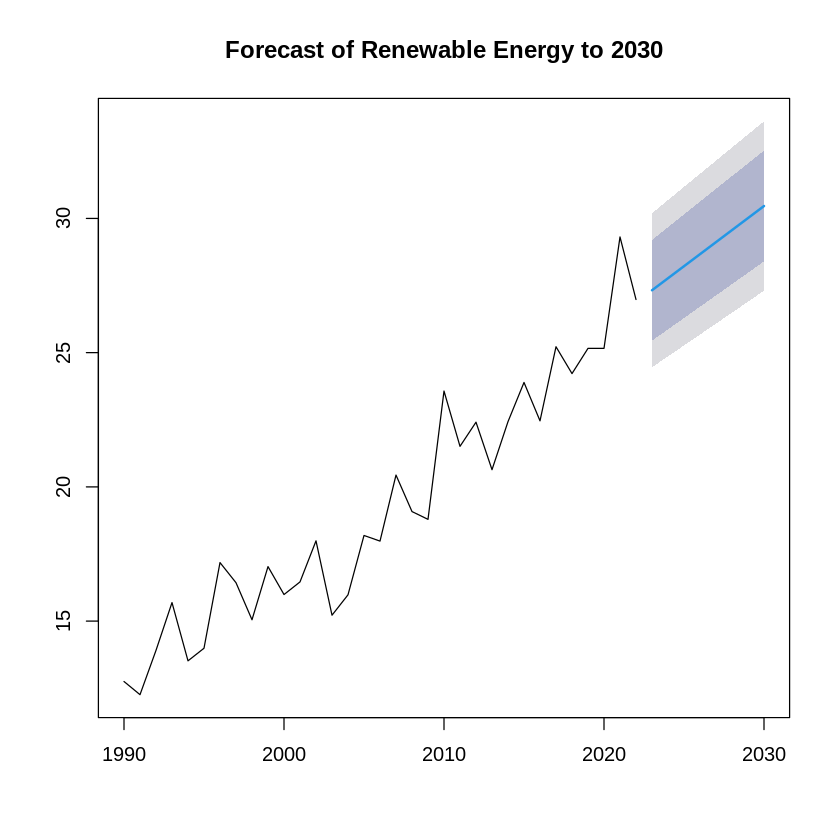

In [20]:
forecasted <- forecast(model, h = 8)  # 2023 to 2030
plot(forecasted, main = "Forecast of Renewable Energy to 2030")
forecasted

In [31]:
step6_2030 <- forecasted$margin[8, ]
# 80% Confidence Interval (2030)
lo_80 <- forecasted$lower[8, "80%"]
hi_80 <- forecasted$upper[8, "80%"]

# 95% Confidence Interval (2030)
lo_95 <- forecasted$lower[8, "95%"]
hi_95 <- forecasted$upper[8, "95%"]

# Print the intervals
cat("2030 80% Confidence Interval:", round(lo_80, 2), "% to", round(hi_80, 2), "%\n")
cat("2030 95% Confidence Interval:", round(lo_95, 2), "% to", round(hi_95, 2), "%\n")

2030 80% Confidence Interval: 28.4 % to 32.52 %
2030 95% Confidence Interval: 27.31 % to 33.62 %


Prompt: Interpret the confidence intervals.

The widening confidence bands from 2023 to 2030 show increasing uncertainty over time

The point forecast for 2030 is 30.46%, with an 80% confidence range of 28.39% – 32.52% and a 95% confidence range of 27.30% – 33.61%.


Step 7 – Modify and Extend

     Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
2023       27.32382 25.44798 29.19966 24.45497 30.19267
2024       27.77212 25.86849 29.67575 24.86077 30.68347
2025       28.22041 26.28939 30.15143 25.26717 31.17365
2026       28.66871 26.71068 30.62674 25.67416 31.66325
2027       29.11700 27.13233 31.10167 26.08171 32.15229
2028       29.56530 27.55434 31.57625 26.48981 32.64079
2029       30.01359 27.97669 32.05049 26.89842 33.12877
2030       30.46189 28.39936 32.52441 27.30753 33.61625
2031       30.91018 28.82235 32.99801 27.71712 34.10324
2032       31.35848 29.24564 33.47131 28.12717 34.58978
2033       31.80677 29.66922 33.94432 28.53767 35.07587
2034       32.25506 30.09309 34.41704 28.94861 35.56152
2035       32.70336 30.51723 34.88949 29.35996 36.04676
2036       33.15165 30.94163 35.36168 29.77171 36.53160
2037       33.59995 31.36629 35.83361 30.18386 37.01604

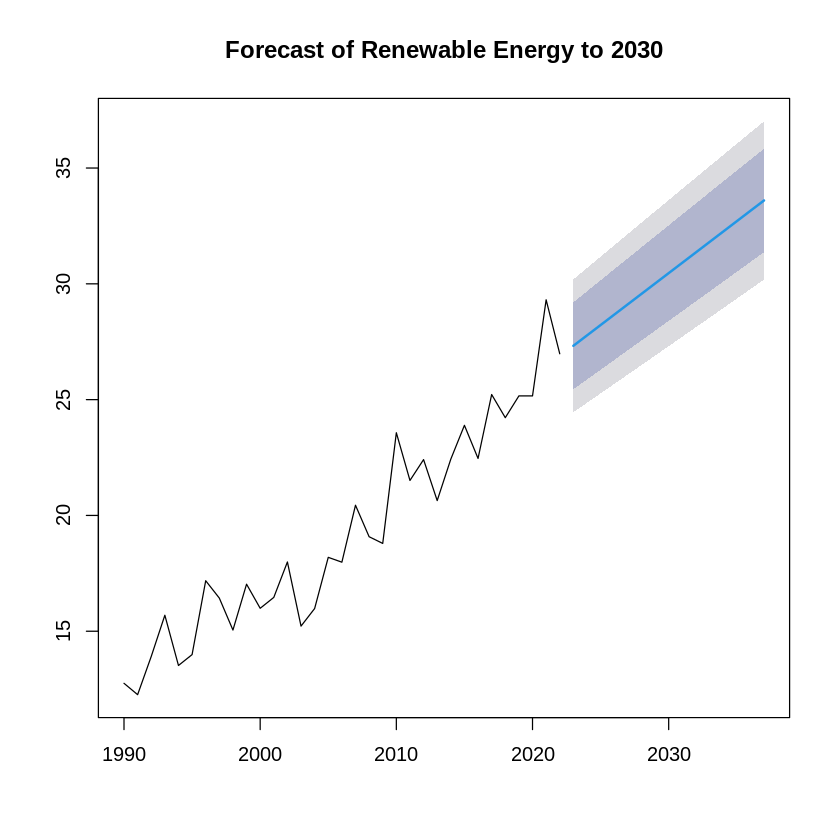

In [29]:
#Changing the forecast horizon (h = 15 for 2023-2030)
forecasted <- forecast(model, h = 15)  # 2023 to 2030
plot(forecasted, main = "Forecast of Renewable Energy to 2030")
forecasted

Series: log_ts 
ARIMA(2,1,0) with drift 

Coefficients:
          ar1      ar2   drift
      -0.6834  -0.5564  0.0246
s.e.   0.1451   0.1451  0.0059

sigma^2 = 0.005898:  log likelihood = 37.82
AIC=-67.65   AICc=-66.16   BIC=-61.78

Training set error measures:
                        ME       RMSE        MAE         MPE     MAPE      MASE
Training set -2.121013e-05 0.07199155 0.05741107 -0.04556381 1.968135 0.6656639
                   ACF1
Training set -0.1128672

     Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
2023       27.71195 25.11451 30.57804 23.83955 32.21337
2024       30.10722 27.15424 33.38132 25.71015 35.25629
2025       29.61611 26.64741 32.91553 25.19831 34.80844
2026       30.22101 26.68477 34.22586 24.98351 36.55647
2027       31.78441 27.88113 36.23414 26.01282 38.83658
2028       32.08407 28.02365 36.73281 26.08655 39.46048
2029       32.75277 28.32780 37.86894 26.23276 40.89328
2030       33.94611 29.17131 39.50245 26.92189 42.80303

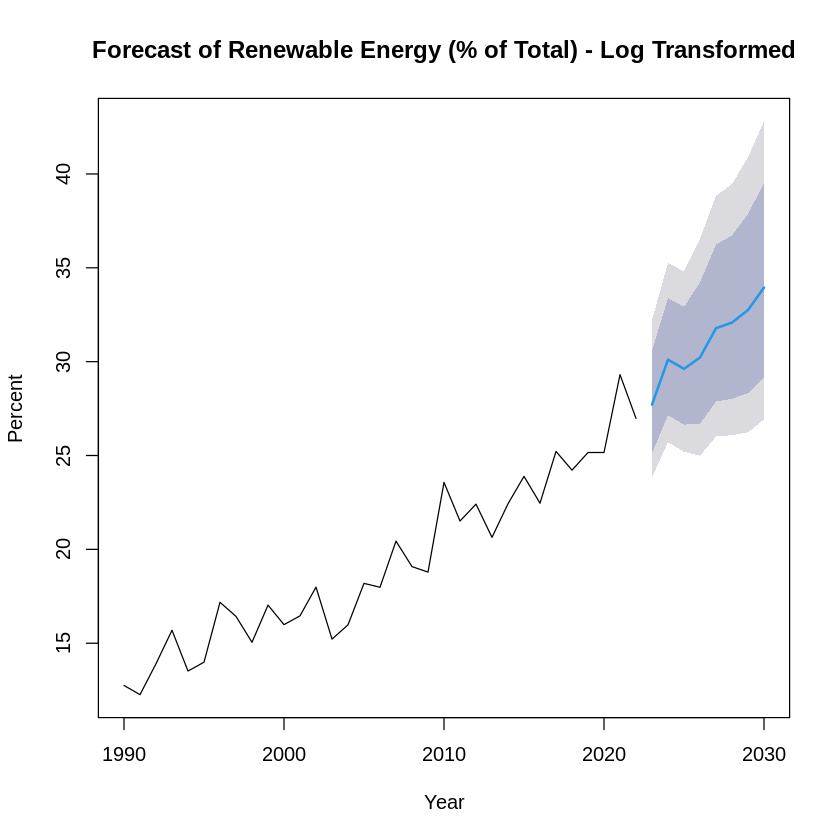

In [22]:
#Using log(ts_data) before modeling
# 1. Transform the time series to log scale
log_ts <- log(ts_data)

# 2. Fit the auto.arima model on log-transformed data
log_model <- auto.arima(log_ts)
summary(log_model)

# 3. Forecast future values (h = 8 for 2023 to 2030)
log_forecast <- forecast(log_model, h = 8)

# 4. Back-transform predictions and confidence intervals to the original percentage scale
forecast_original <- log_forecast
forecast_original$mean <- exp(log_forecast$mean)
forecast_original$lower <- exp(log_forecast$lower)
forecast_original$upper <- exp(log_forecast$upper)
forecast_original$x <- exp(log_forecast$x)

# 5. Plot the back-transformed forecasts
plot(forecast_original, main = "Forecast of Renewable Energy (% of Total) - Log Transformed",
     ylab = "Percent", xlab = "Year")

# View numerical predictions on the original scale
forecast_original


	Ljung-Box test

data:  Residuals from ARIMA(0,1,1) with drift
Q* = 3.6527, df = 6, p-value = 0.7236

Model df: 1.   Total lags used: 7



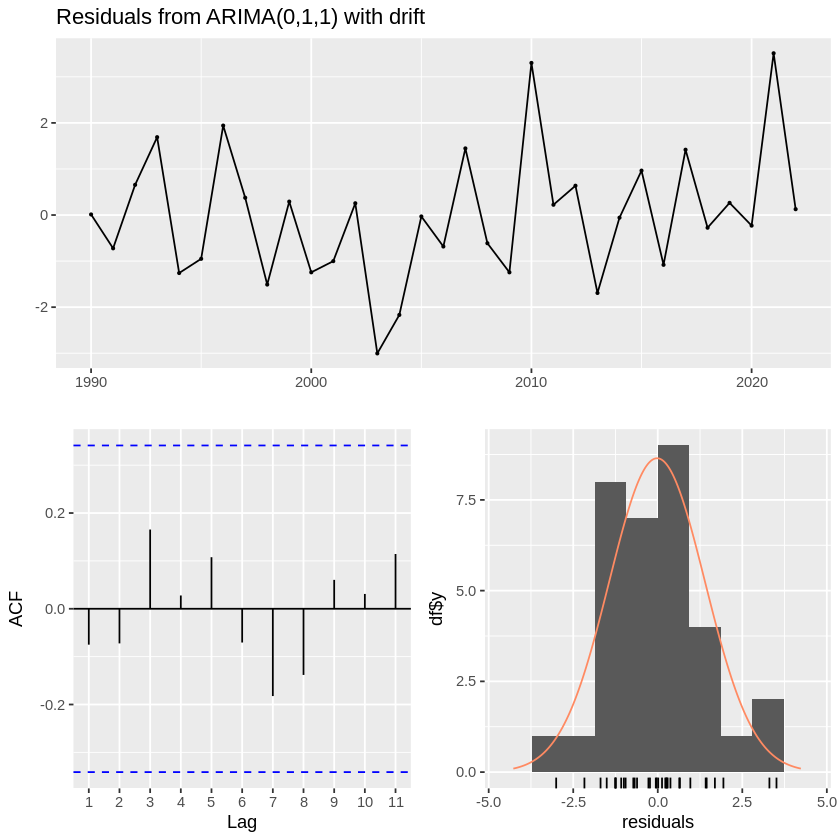

In [23]:
#Plotting residuals: checkresiduals(model)
checkresiduals(model)

Question: How sensitive is your model to small changes in assumptions?

-The model is moderately sensitive: switching from standard linear growth to a log transformation increases the 2030 point forecast from 30.46% to 33.95% and nearly doubles the width of the 95% confidence interval (from 27.31%–33.62% up to 26.92%–42.80%).

Step 8 – Enhanced Visualization with ggplot2

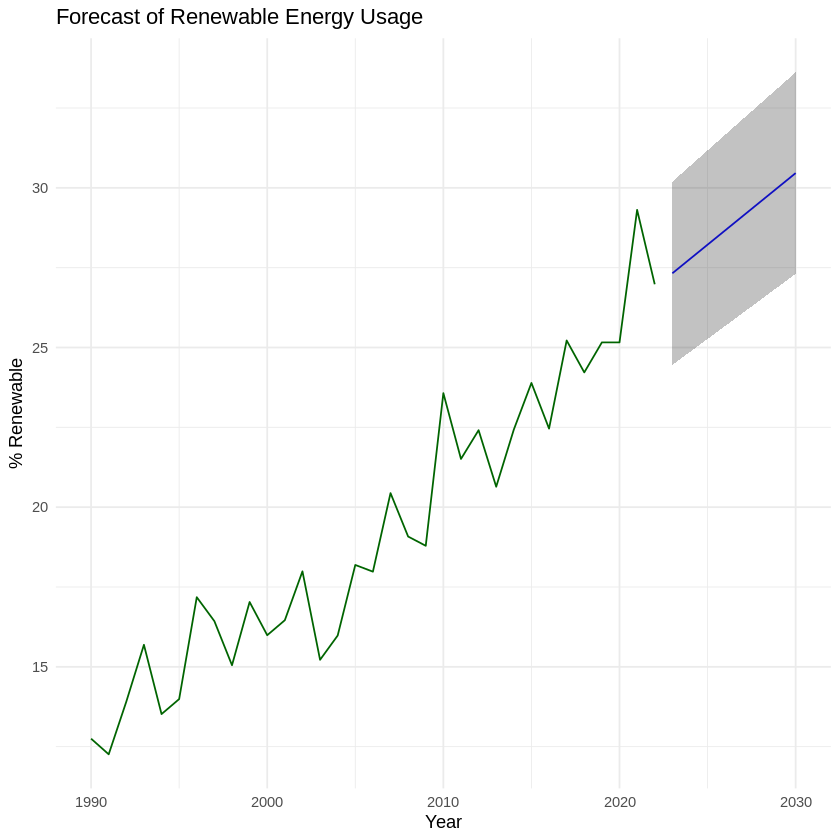

In [26]:
# Convert forecast to data frame for plotting
forecast_df <- data.frame(
  Year = 2023:2030,
  Forecast = forecasted$mean,
  Lower = forecasted$lower[,2],
  Upper = forecasted$upper[,2]
)

ggplot() +
  geom_line(data = data, aes(x = Year, y = Renewable_Energy_Percent), color = "darkgreen") +
  geom_line(data = forecast_df, aes(x = Year, y = Forecast), color = "blue") +
  geom_ribbon(data = forecast_df, aes(x = Year, ymin = Lower, ymax = Upper), alpha = 0.3) +
  labs(title = "Forecast of Renewable Energy Usage", y = "% Renewable", x = "Year") +
  theme_minimal()

Step 9 – Explore What-If Scenarios

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


,Year,Baseline,Accelerated,Lower_95,Upper_95
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
8,2030,30.46189,46.46189,43.30753,49.61625


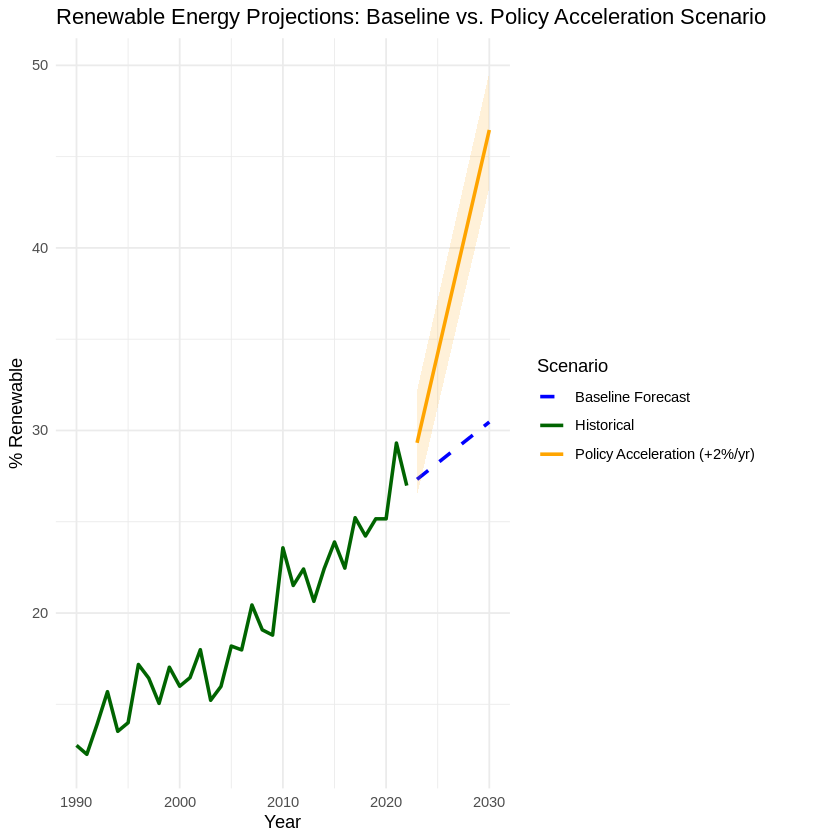

In [27]:
#What if policy changes accelerate growth by 2% yearly?
# 1. Calculate accelerated forecast (+2% additional growth per year)
years <- 2023:2030
growth_boost <- 2 * (1:length(years))  # Cumulative +2% each year
accelerated_forecast <- forecasted$mean + growth_boost

# 2. Build scenario comparison data frame
scenario_df <- data.frame(
  Year = years,
  Baseline = forecasted$mean,
  Accelerated = accelerated_forecast,
  Lower_95 = forecasted$lower[, 2] + growth_boost,
  Upper_95 = forecasted$upper[, 2] + growth_boost
)

# 3. Plot Baseline vs. Accelerated Policy Scenario
ggplot() +
  geom_line(data = data, aes(x = Year, y = Renewable_Energy_Percent, color = "Historical"), size = 1) +
  geom_line(data = scenario_df, aes(x = Year, y = Baseline, color = "Baseline Forecast"), size = 1, linetype = "dashed") +
  geom_line(data = scenario_df, aes(x = Year, y = Accelerated, color = "Policy Acceleration (+2%/yr)"), size = 1) +
  geom_ribbon(data = scenario_df, aes(x = Year, ymin = Lower_95, ymax = Upper_95), fill = "orange", alpha = 0.15) +
  scale_color_manual(values = c("Historical" = "darkgreen", "Baseline Forecast" = "blue", "Policy Acceleration (+2%/yr)" = "orange")) +
  labs(title = "Renewable Energy Projections: Baseline vs. Policy Acceleration Scenario",
       y = "% Renewable", x = "Year", color = "Scenario") +
  theme_minimal()

# Display 2030 Comparison
tail(scenario_df, 1)

,Year,Forecast,Lower_Volatile,Upper_Volatile
,<int>,<dbl>,<dbl>,<dbl>
8,2030,30.46189,25.73035,35.19343


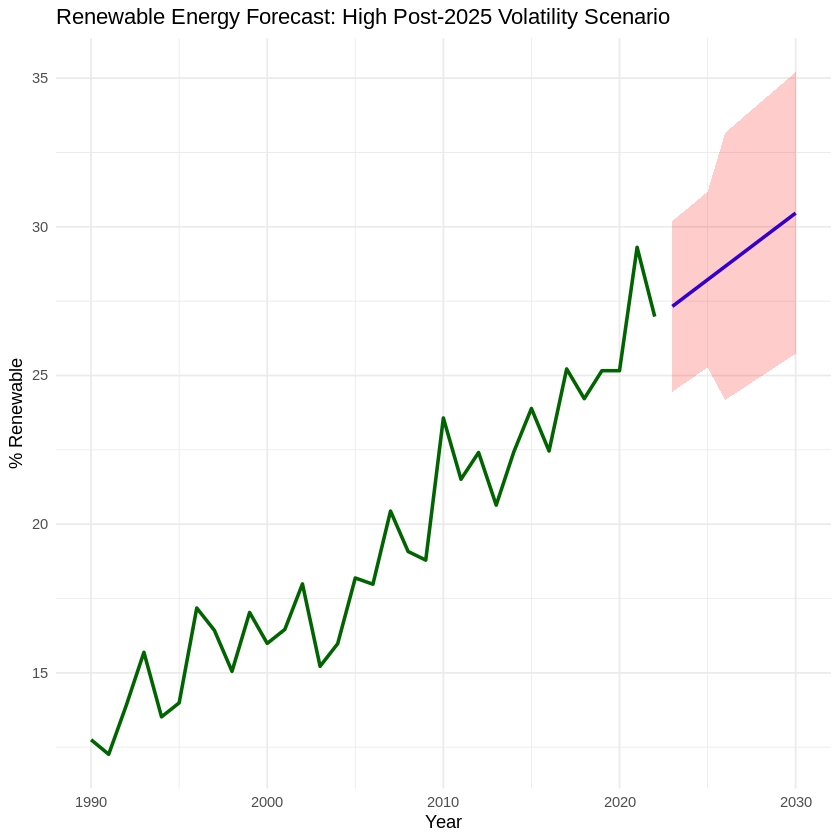

In [28]:
#What if volatility increases after 2025?
# 1. Base forecast data frame
vol_df <- data.frame(
  Year = 2023:2030,
  Forecast = forecasted$mean,
  Lower_95 = forecasted$lower[, 2],
  Upper_95 = forecasted$upper[, 2]
)

# 2. Apply a variance expansion factor post-2025 (e.g., 50% wider intervals)
post_2025_idx <- vol_df$Year > 2025
vol_df$Lower_Volatile <- vol_df$Lower_95
vol_df$Upper_Volatile <- vol_df$Upper_95

# Expand lower and upper bounds relative to the point forecast starting in 2026
vol_df$Lower_Volatile[post_2025_idx] <- vol_df$Forecast[post_2025_idx] -
  (vol_df$Forecast[post_2025_idx] - vol_df$Lower_95[post_2025_idx]) * 1.5

vol_df$Upper_Volatile[post_2025_idx] <- vol_df$Forecast[post_2025_idx] +
  (vol_df$Upper_95[post_2025_idx] - vol_df$Forecast[post_2025_idx]) * 1.5

# 3. Plot Baseline vs High Volatility Scenario
ggplot() +
  geom_line(data = data, aes(x = Year, y = Renewable_Energy_Percent), color = "darkgreen", linewidth = 1) +
  geom_line(data = vol_df, aes(x = Year, y = Forecast), color = "blue", linewidth = 1) +
  geom_ribbon(data = vol_df, aes(x = Year, ymin = Lower_Volatile, ymax = Upper_Volatile),
              fill = "red", alpha = 0.2) +
  labs(title = "Renewable Energy Forecast: High Post-2025 Volatility Scenario",
       y = "% Renewable", x = "Year") +
  theme_minimal()

# View expanded 2030 interval
tail(vol_df[, c("Year", "Forecast", "Lower_Volatile", "Upper_Volatile")], 1)